In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#scelgo la funzione
fx= lambda x: np.sin(x)

scrivere questa cosa è equivalente a scrivere lambda è un alias  per scrivere una funzione quello che sta a sinistra dei due punti gli argomenti a destra cosa deve fare la funzione

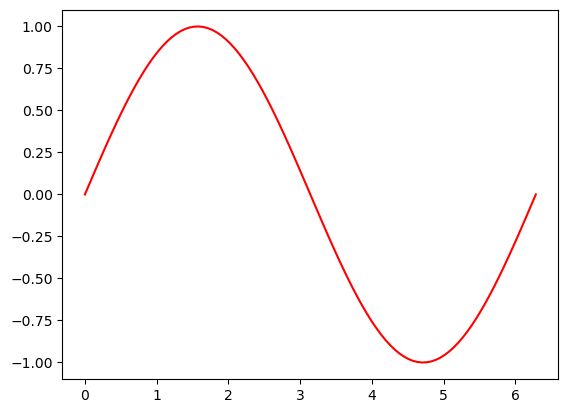

In [3]:
x_points= np.linspace(0,2*np.pi,100)
y_points= fx(x_points)

plt.plot(x_points,y_points, color='red')
plt.show()

In [4]:
def linear_interpolation(x,x_nodes,y_nodes):
  #compute the index
  index= np.digitize(x,x_nodes)-1

  #compute te interpolad value
  y= y_nodes[index]+(x-x_nodes[index])*(y_nodes[index+1]-y_nodes[index])/(x_nodes[index+1]-x_nodes[index])

  return y


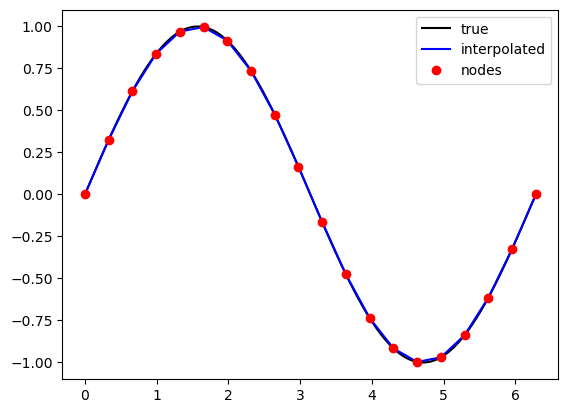

In [5]:
x_nodes = np.linspace(0,2*np.pi,20)
y_nodes = fx(x_nodes)
x_interp= np.linspace(0,2*np.pi*0.999,100)
y_interp= linear_interpolation(x_interp,x_nodes,y_nodes)

plt.plot(x_points,y_points, color='k')
plt.plot(x_interp ,y_interp,  color='b')
plt.plot(x_nodes, y_nodes, "or")
plt.legend(["true", "interpolated", "nodes"])
plt.show()



In [6]:
#x_true= fx(x_interp)
y_true= fx(x_interp)

diff = np.abs(y_interp-y_true)

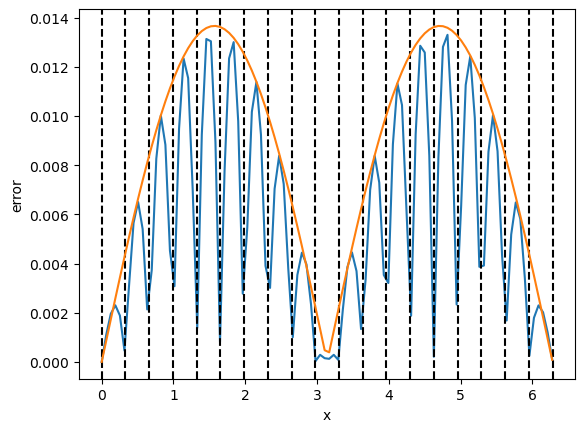

In [7]:
plt.plot(x_interp,diff)
plt.xlabel("x")
plt.ylabel("error")

for i in range(len(x_nodes)):
  plt.axvline(x=x_nodes[i], color='k' , linestyle='--')

plt.plot(x_interp, np.abs(np.sin(x_interp)* (x_nodes[1]-x_nodes[0])**2/8))
plt.show()




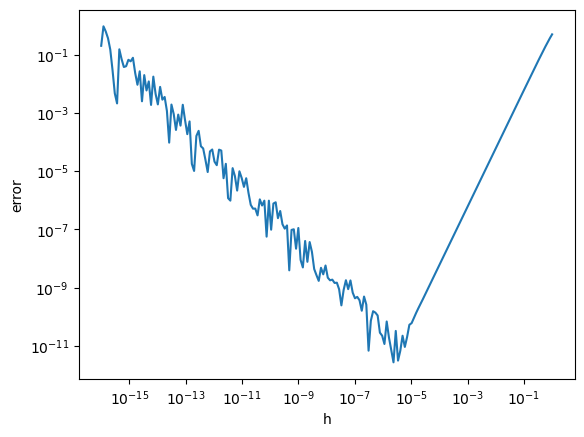

In [8]:
#Differentiation

#provo a riprodurre il plot di prima faccio una lista di valori di h
hlist= np.logspace(-16,0,200)
fx= lambda x: np.sin(x)**2

#in questo caso per ogni valore di x calcolo la derivata al primo ordine esp lineare in un punto che scegliamo noi

x_cen= 1
err_1 = []
for i in range(len(hlist)):
  diff_1= (fx(x_cen+hlist[i])-fx(x_cen-hlist[i])) / (2*hlist[i])
  err_1.append(np.abs(diff_1 - 2* np.sin(x_cen) * np.cos(x_cen)))

plt.loglog(hlist, err_1)
plt.xlabel("h")
plt.ylabel("error")
plt.show()

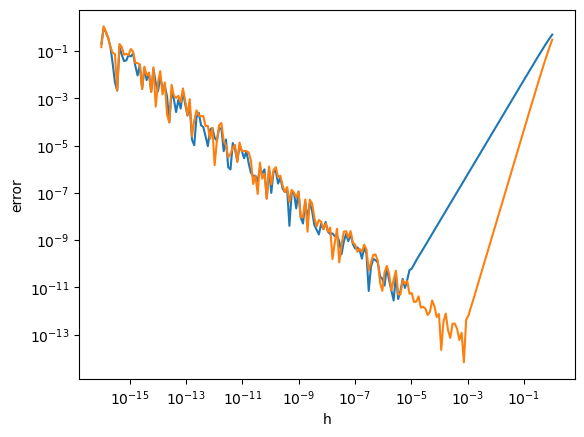

In [9]:
#aggiungismo un sltro modo per fare le derivate
#ad ordine più alto + h e -2h da moltiplicare per due  terzi e meno

#provo a riprodurre il plot di prima faccio una lista di valori di h
hlist= np.logspace(-16,0,200)
fx= lambda x: np.sin(x)**2

#in questo caso per ogni valore di x calcolo la derivata al primo ordine esp lineare in un punto che scegliamo noi

x_cen= 1
err_1 = []
err_2 =[]
for i in range(len(hlist)):
  diff_1= (fx(x_cen+hlist[i])-fx(x_cen-hlist[i])) / (2*hlist[i])
  diff_2= (2./3*fx(x_cen+hlist[i])-2./3*fx(x_cen-hlist[i])- 1./12* fx(x_cen+2*hlist[i])+ 1./12* fx(x_cen-2*hlist[i]) ) / hlist[i]
  err_1.append(np.abs(diff_1 - 2* np.sin(x_cen) * np.cos(x_cen)))
  err_2.append(np.abs(diff_2 - 2* np.sin(x_cen) * np.cos(x_cen)))

plt.loglog(hlist, err_1)
plt.loglog(hlist, err_2)
plt.xlabel("h")
plt.ylabel("error")
plt.show()